In [64]:
# from read_multi_ase_simple import *
from extract_simple import *

import torch
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt

# from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool, Sequential
from torch_geometric.loader import DataLoader
from tqdm import tqdm

In [65]:
my_path = '../../data'
MAX_MOLS = 200

files_list = find_files(my_path)

# Process files from list and extract specified number of molecules and type
dataset = process_file(files_list, molecule_type = 'biomolecules', max_molecules = MAX_MOLS)

# Get final dataset for use with PyG 
torch_data = get_data(dataset)

final_dataset = split_data(torch_data, 0.8)

Processed 200 atoms


In [66]:
train_dataset = final_dataset[0]
val_dataset = final_dataset[1]

print(len(train_dataset), len(val_dataset))

160 40


In [67]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [68]:
# inherit from nn.Module 
class SimpleGNN(nn.Module):
    def __init__(self, num_node_features=1, hidden_channels=64):
        # call constructor from parent class 
        super().__init__()

        self.simpleGNN = Sequential('x, edge_index, batch', [
            # CONVOLUTION LAYERS: learn molecular represenation 
            # layer 1: directly bonded atoms
            (GCNConv(num_node_features, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 2: local chemical environment (i.e., funct groups)
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 3: adds global context
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),

            # POOLING: down-sample/reduce dimensions 
            (global_mean_pool, 'x, batch -> x'),

            # LINEAR LAYERS: turn into actual predictions 
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)])


    def forward(self, x, edge_index, batch):
        return self.simpleGNN(x, edge_index, batch).reshape(-1)

In [69]:
# code taken from Module 9 bloodmnist_pytroch.ipynb demo 

NUM_EPOCHS = 100

def train_model(model, train_loader, val_loader, loss_fn, optimizer,
                epochs=10, print_every=1, device='cpu'):

    # for storing losses for plotting 
    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': [], 'train_mse': [], 'val_mse': []}

    model = model.to(device) # move to device (cpu/gpu/mps as specified)

    for epoch in tqdm(range(epochs), desc='Training'):
        # TRAINING
        model.train()
        
        # initialize losses to 0
        epoch_train_loss = 0.0
        epoch_train_mae = 0.0

        # iterate thru each batch 
        for batch in train_loader:
            batch = batch.to(device) # move to specified device 

            # inputs [x, edge_index, batch]
            predictions = model(batch.x, batch.edge_index, batch.batch)
            targets = batch.y.reshape(-1).float() # reshape 

            # compare to target and calculate loss 
            loss = loss_fn(predictions, targets)

            optimizer.zero_grad() # zero out grads
            loss.backward() # back-prop 
            optimizer.step() # update/adjust 

            epoch_train_loss += loss.item() # add to running loss 
            epoch_train_mae += torch.mean(torch.abs(predictions - targets)).item() 

        # calculate avg losses 
        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_train_mae = epoch_train_mae / len(train_loader)

        # Validation
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_mae = 0.0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)

                predictions = model(batch.x, batch.edge_index, batch.batch)
                targets = batch.y.reshape(-1).float()

                loss = loss_fn(predictions, targets)

                epoch_val_loss += loss.item()
                epoch_val_mae += torch.mean(torch.abs(predictions - targets)).item()

        avg_val_loss = epoch_val_loss / len(val_loader)
        avg_val_mae = epoch_val_mae / len(val_loader)

        # Record
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_mae'].append(avg_train_mae)
        history['val_mae'].append(avg_val_mae)

        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {avg_val_loss:.4f} | "
                f"Train MAE: {avg_train_mae:.4f} | "
                f"Val MAE: {avg_val_mae:.4f}"
            )

    return history


In [76]:
def plot_losses(history):
    """Plot training vs validation loss from a history dict."""
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
    plt.plot(history['val_loss'], label='Validation Loss',
             linewidth=2, linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('MAE Loss')
    plt.title('simpleGNN Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [71]:
# initialize model 
simpleGNN = SimpleGNN()
print(simpleGNN)

SimpleGNN(
  (simpleGNN): Sequential(
    (0) - GCNConv(1, 64): x, edge_index -> x
    (1) - ReLU(): x -> x
    (2) - GCNConv(64, 64): x, edge_index -> x
    (3) - ReLU(): x -> x
    (4) - GCNConv(64, 64): x, edge_index -> x
    (5) - ReLU(): x -> x
    (6) - <function global_mean_pool at 0x1694084c0>: x, batch -> x
    (7) - Linear(in_features=64, out_features=64, bias=True): x -> x
    (8) - ReLU(): x -> x
    (9) - Linear(in_features=64, out_features=64, bias=True): x -> x
    (10) - ReLU(): x -> x
    (11) - Linear(in_features=64, out_features=1, bias=True): x -> x
  )
)


In [72]:
my_lr = 1e-3
my_loss_fn = nn.MSELoss()
my_optimizer = optim.Adam(simpleGNN.parameters(), lr=my_lr)

In [73]:
simpleGNN.parameters()

<generator object Module.parameters at 0x873131070>

In [74]:
history = train_model(
    model = simpleGNN, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    loss_fn = my_loss_fn,
    optimizer = my_optimizer,
    epochs = 100,
    print_every = 5
)

Training:   7%|▋         | 7/100 [00:00<00:07, 12.32it/s]

Epoch   5/100 | Train Loss: 56.3972 | Val Loss: 46.9420 | Train MAE: 7.2341 | Val MAE: 6.5307


Training:  11%|█         | 11/100 [00:00<00:07, 12.35it/s]

Epoch  10/100 | Train Loss: 10.3005 | Val Loss: 6.3433 | Train MAE: 2.6432 | Val MAE: 2.0125


Training:  17%|█▋        | 17/100 [00:01<00:06, 12.58it/s]

...

Epoch  90/100 | Train Loss: 5.7023 | Val Loss: 5.4340 | Train MAE: 1.9369 | Val MAE: 1.8307


Training:  97%|█████████▋| 97/100 [00:07<00:00, 12.17it/s]

Epoch  95/100 | Train Loss: 5.6160 | Val Loss: 5.3023 | Train MAE: 1.9204 | Val MAE: 1.7912


Training: 100%|██████████| 100/100 [00:08<00:00, 12.14it/s]

Epoch 100/100 | Train Loss: 5.5116 | Val Loss: 5.3109 | Train MAE: 1.8899 | Val MAE: 1.7979


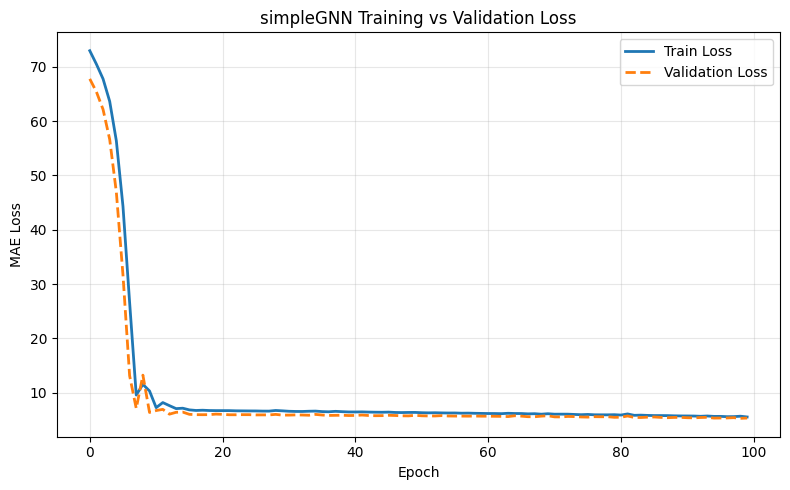

In [77]:
plot_losses(history)